## Import libs

In [1]:
from tensorflow.python.data import Dataset
from sklearn.model_selection import train_test_split
import seaborn as sns
import pandas as pd


from falsb4mpa.dataset.load_data import load_data
from falsb4mpa.evaluation.evaluation import compute_predictive_metrics, compute_fair_metrics, compute_tradeoff, compute_intersectional_fair_metrics
from falsb4mpa.modeling.sk_vanilla.vanilla_lr import VanillaLogisticRegression

## Preliminaries

In [2]:
batch_size = 64
epochs = 100
learning_rate = 0.001

In [3]:
# cv_seeds = [13]
cv_seeds = [13, 29, 42, 55, 73]

## Load data

In [4]:
data_name = 'german-mpa-bin-wout-agg'

In [5]:
x, y, a1, a2 = load_data(data_name)
raw_data = (x, y, a1, a2)

In [6]:
xdim = x.shape[1]
ydim = y.shape[1]
a1dim = a1.shape[1]
a2dim = a2.shape[1]
zdim = 8
print(xdim, ydim, a1dim, a2dim, zdim)

28 1 1 1 8


## Result file

In [7]:
header = [
    "model_name", "cv_seed", 
    "clas_acc", "f1-micro", "f1-macro",
    "a1_dp", "a1_deqodds", "a1_deqopp", 
    "a1_TN_g0", "a1_FP_g0", "a1_FN_g0", "a1_TP_g0", "a1_TN_g1", "a1_FP_g1", "a1_FN_g1", "a1_TP_g1", 
    "a2_dp", "a2_deqodds", "a2_deqopp", 
    "a2_TN_g0", "a2_FP_g0", "a2_FN_g0", "a2_TP_g0", "a2_TN_g1", "a2_FP_g1", "a2_FN_g1", "a2_TP_g1",
    "wc_spd", "wc_aod", "wc_eod"
]

results = []

## Testing

In [8]:
results= []
for cv_seed in cv_seeds:
        x_train, x_test, y_train, y_test, a1_train, a1_test, a2_train, a2_test = train_test_split(
                x, y, a1, a2, test_size=0.3, random_state=cv_seed
        )
        y_train = y_train.ravel()
        y_test = y_test.ravel()
        
        model = VanillaLogisticRegression(epochs, learning_rate)

        train_data = Dataset.from_tensor_slices((x_train, y_train, a1_train, a2_train))
        train_data = train_data.batch(batch_size, drop_remainder=True)

        test_data = Dataset.from_tensor_slices((x_test, y_test, a1_test, a2_test))
        test_data = test_data.batch(batch_size, drop_remainder=True)

        for epoch in range(epochs):
                for X, Y, A1, A2 in train_data:
                        model.partial_fit(X, Y)

         
        Y_hat = model.predict(x_test)

        clas_acc, clas_f1_micro, clas_f1_macro, confusion_matrix = compute_predictive_metrics(y_test, Y_hat)
        
        a1_dp, a1_deqodds, a1_deqopp, a1_metrics_g0, a1_metrics_g1 = compute_fair_metrics(y_test, a1_test, Y_hat, a1dim)
        a2_dp, a2_deqodds, a2_deqopp, a2_metrics_g0, a2_metrics_g1 = compute_fair_metrics(y_test, a2_test, Y_hat, a2dim)

        wc_spd, wc_aod, wc_eod = compute_intersectional_fair_metrics(y_test, a1_test, a2_test, Y_hat, a1dim, a2dim)
        
        # fair_metrics = (dp, deqodds, deqopp)
        
        # tradeoff = []
        
        # for fair_metric in fair_metrics:
        #         tradeoff.append(compute_tradeoff(clas_acc, fair_metric))
        
        # result = ['UnfairLR-decay', cv_seed, clas_acc, dp, deqodds, deqopp, tradeoff[0], tradeoff[1], tradeoff[2]]

        result = ['SkVanillaLR', cv_seed]
        result += [clas_acc, clas_f1_micro, clas_f1_macro]
        result += [a1_dp, a1_deqodds, a1_deqopp] + a1_metrics_g0 + a1_metrics_g1 
        result += [a2_dp, a2_deqodds, a2_deqopp] + a2_metrics_g0 + a2_metrics_g1
        result += [wc_spd, wc_aod, wc_eod]

        results.append(result)
        

2026-05-14 16:19:56.144705: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-05-14 16:19:56.147851: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-05-14 16:19:56.152583: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-05-14 16:19:56.160424: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-05-14 16:19:56.176147: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-05-14 16:19:56.206701: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-05-14 16:19:56.267277: I tensorflow/core/framework/local_rendezvous.cc:405] L

> Predictive Performance Evaluation
> Class Acc = 0.7166666388511658
> Confusion Matrix 
TN: 31.0 | FP: 48.0 
FN: 37.0 | TP: 184.0
> Fairness Evaluation
> DP | DEqOdds | DEqOpp
> 0.8169721961021423 | 0.7540150880813599 | 0.923202633857727
> Confusion Matrix for A = 0 
TN: 19.0 | FP: 10.0 
FN: 15.0 | TP: 53.0
> Confusion Matrix for A = 1 
TN: 12.0 | FP: 38.0 
FN: 22.0 | TP: 131.0
> Fairness Evaluation
> DP | DEqOdds | DEqOpp
> 0.7894242405891418 | 0.762366533279419 | 0.8396210074424744
> Confusion Matrix for A = 0 
TN: 12.0 | FP: 34.0 
FN: 15.0 | TP: 124.0
> Confusion Matrix for A = 1 
TN: 19.0 | FP: 14.0 
FN: 22.0 | TP: 60.0
> Intersectional Fairness Evaluation
> WC_SPD | WC_AOD | WC_EOD
> 0.6559614539146423 | 0.5952904224395752 | 0.7604166269302368


2026-05-14 16:19:56.465360: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
/Users/lffpl/Projects/falsb4mpa/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:205: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/lffpl/Projects/falsb4mpa/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:205: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/lffpl/Projects/falsb4mpa/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:205: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


> Predictive Performance Evaluation
> Class Acc = 0.7200000286102295
> Confusion Matrix 
TN: 32.0 | FP: 66.0 
FN: 18.0 | TP: 184.0
> Fairness Evaluation
> DP | DEqOdds | DEqOpp
> 0.8922130465507507 | 0.9238748550415039 | 0.9161707162857056
> Confusion Matrix for A = 0 
TN: 14.0 | FP: 24.0 
FN: 8.0 | TP: 45.0
> Confusion Matrix for A = 1 
TN: 18.0 | FP: 42.0 
FN: 10.0 | TP: 139.0
> Fairness Evaluation
> DP | DEqOdds | DEqOpp
> 0.8167155385017395 | 0.8143362998962402 | 0.8736559152603149
> Confusion Matrix for A = 0 
TN: 11.0 | FP: 41.0 
FN: 5.0 | TP: 119.0
> Confusion Matrix for A = 1 
TN: 21.0 | FP: 25.0 
FN: 13.0 | TP: 65.0
> Intersectional Fairness Evaluation
> WC_SPD | WC_AOD | WC_EOD
> 0.7643218636512756 | 0.7869071960449219 | 0.8062705993652344


2026-05-14 16:19:56.789159: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
/Users/lffpl/Projects/falsb4mpa/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:205: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/lffpl/Projects/falsb4mpa/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:205: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/lffpl/Projects/falsb4mpa/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:205: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


> Predictive Performance Evaluation
> Class Acc = 0.7333333492279053
> Confusion Matrix 
TN: 26.0 | FP: 65.0 
FN: 15.0 | TP: 194.0
> Fairness Evaluation
> DP | DEqOdds | DEqOpp
> 0.8878645300865173 | 0.8598532676696777 | 0.9583050608634949
> Confusion Matrix for A = 0 
TN: 13.0 | FP: 16.0 
FN: 6.0 | TP: 53.0
> Confusion Matrix for A = 1 
TN: 13.0 | FP: 49.0 
FN: 9.0 | TP: 141.0
> Fairness Evaluation
> DP | DEqOdds | DEqOpp
> 0.8987842798233032 | 0.8768177628517151 | 0.9575570821762085
> Confusion Matrix for A = 0 
TN: 10.0 | FP: 41.0 
FN: 7.0 | TP: 120.0
> Confusion Matrix for A = 1 
TN: 16.0 | FP: 24.0 
FN: 8.0 | TP: 74.0
> Intersectional Fairness Evaluation
> WC_SPD | WC_AOD | WC_EOD
> 0.8360186219215393 | 0.7907603979110718 | 0.898809552192688


/Users/lffpl/Projects/falsb4mpa/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:205: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/lffpl/Projects/falsb4mpa/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:205: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/lffpl/Projects/falsb4mpa/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:205: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


> Predictive Performance Evaluation
> Class Acc = 0.70333331823349
> Confusion Matrix 
TN: 30.0 | FP: 59.0 
FN: 30.0 | TP: 181.0
> Fairness Evaluation
> DP | DEqOdds | DEqOpp
> 0.8575469851493835 | 0.8301215171813965 | 0.9060057401657104
> Confusion Matrix for A = 0 
TN: 15.0 | FP: 15.0 
FN: 14.0 | TP: 54.0
> Confusion Matrix for A = 1 
TN: 15.0 | FP: 44.0 
FN: 16.0 | TP: 127.0
> Fairness Evaluation
> DP | DEqOdds | DEqOpp
> 0.7597597241401672 | 0.7303363680839539 | 0.8275490403175354
> Confusion Matrix for A = 0 
TN: 10.0 | FP: 43.0 
FN: 11.0 | TP: 125.0
> Confusion Matrix for A = 1 
TN: 20.0 | FP: 16.0 
FN: 19.0 | TP: 56.0
> Intersectional Fairness Evaluation
> WC_SPD | WC_AOD | WC_EOD
> 0.6061872839927673 | 0.5672123432159424 | 0.6701388955116272
> Predictive Performance Evaluation
> Class Acc = 0.7400000095367432
> Confusion Matrix 
TN: 30.0 | FP: 56.0 
FN: 22.0 | TP: 192.0
> Fairness Evaluation
> DP | DEqOdds | DEqOpp
> 0.9580665230751038 | 0.9443969130516052 | 0.9750683307647705


/Users/lffpl/Projects/falsb4mpa/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:205: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/lffpl/Projects/falsb4mpa/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:205: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/lffpl/Projects/falsb4mpa/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:205: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


In [9]:
print(clas_acc, clas_f1_micro, clas_f1_macro)

0.74 0.74 0.6329757199322417


<Axes: >

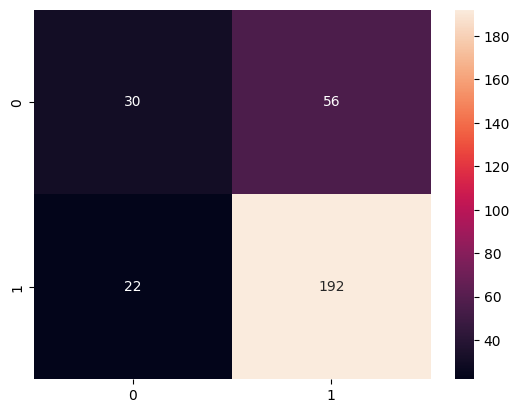

In [10]:
sns.heatmap(confusion_matrix, annot=True, fmt='g')

## Saving into DF then CSV

In [11]:
result_df = pd.DataFrame(results, columns=header)
result_df

,model_name,cv_seed,clas_acc,f1-micro,f1-macro,a1_dp,a1_deqodds,a1_deqopp,a1_TN_g0,a1_FP_g0,...,a2_FP_g0,a2_FN_g0,a2_TP_g0,a2_TN_g1,a2_FP_g1,a2_FN_g1,a2_TP_g1,wc_spd,wc_aod,wc_eod
0,SkVanillaLR,13,0.716667,0.716667,0.617065,0.816972,0.754015,0.923203,19.0,10.0,...,34.0,15.0,124.0,19.0,14.0,22.0,60.0,0.655961,0.595290,0.760417
1,SkVanillaLR,29,0.720000,0.720000,0.623296,0.892213,0.923875,0.916171,14.0,24.0,...,41.0,5.0,119.0,21.0,25.0,13.0,65.0,0.764322,0.786907,0.806271
2,SkVanillaLR,42,0.733333,0.733333,0.611500,0.887865,0.859853,0.958305,13.0,16.0,...,41.0,7.0,120.0,16.0,24.0,8.0,74.0,0.836019,0.790760,0.898810
3,SkVanillaLR,55,0.703333,0.703333,0.602673,0.857547,0.830122,0.906006,15.0,15.0,...,43.0,11.0,125.0,20.0,16.0,19.0,56.0,0.606187,0.567212,0.670139
4,SkVanillaLR,73,0.740000,0.740000,0.632976,0.958067,0.944397,0.975068,14.0,21.0,...,31.0,6.0,129.0,22.0,25.0,16.0,63.0,0.734375,0.735643,0.755556


In [13]:
result_df.to_csv(f'../../results/{data_name}-vanilla_lr-{epochs}.csv')